# Tutorial: Online Conformal Prediction with `online-cp`

This notebook is a comprehensive tutorial for the `online-cp` package. It covers:

1. **Conformal Regressors** — producing prediction intervals with guaranteed coverage
2. **Conformal Classifiers** — producing prediction sets for classification
3. **Conformal Predictive Systems (CPS)** — full predictive distributions
4. **Evaluation** — tracking efficiency criteria online
5. **Conformal Test Martingales** — testing the exchangeability assumption

## Background

Conformal prediction provides distribution-free, finite-sample guarantees on prediction uncertainty. Given exchangeable data $(z_1, z_2, \ldots, z_n)$ and a significance level $\varepsilon \in (0, 1)$, a conformal predictor produces prediction sets $\Gamma^\varepsilon$ satisfying:

$$\mathbb{P}(y_{n+1} \in \Gamma^\varepsilon) \geq 1 - \varepsilon$$

The key idea is to compare a new example's "nonconformity" (how unusual it looks compared to the training set) against the nonconformity of the training examples themselves. If the new example is exchangeable with the training data, its nonconformity score has a known (uniform) distribution regardless of the underlying data-generating process.

The `online-cp` package implements these methods in a fully **online** setting: we observe one example at a time, make a prediction, observe the true label, and update our model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 100

---
## 1. Conformal Regressors

Conformal regressors produce prediction intervals with guaranteed marginal coverage.

### 1.1 Ridge Regression

`ConformalRidgeRegressor` implements Algorithm 2.4 from *Algorithmic Learning in a Random World*. It uses ridge regression as the underlying model and computes exact prediction intervals efficiently via a closed-form solution.

In [2]:
from online_cp import ConformalRidgeRegressor

# Generate synthetic regression data
N = 200
X = np.random.uniform(-2, 2, (N, 3))
beta_true = np.array([2.0, -1.0, 0.5])
y = X @ beta_true + np.random.normal(0, 0.5, N)

print(f"Data: {N} points, {X.shape[1]} features")
print(f"True coefficients: {beta_true}")
print(f"Noise std: 0.5")

Data: 200 points, 3 features
True coefficients: [ 2.  -1.   0.5]
Noise std: 0.5


#### Online learning workflow

The fundamental workflow is:
1. Observe object $x_n$
2. Predict a set $\Gamma^\varepsilon(x_n)$ at significance level $\varepsilon$
3. Observe the true label $y_n$
4. Update the model with $(x_n, y_n)$

In [3]:
# Create regressor with ridge parameter a=1.0 and significance level epsilon=0.1
cp = ConformalRidgeRegressor(a=1.0, epsilon=0.1)

# Process data online
errors = []
widths = []
for i in range(N):
    # Predict
    interval = cp.predict(X[i], epsilon=0.1)

    # Record whether the true label falls outside the prediction set
    errors.append(y[i] not in interval)
    widths.append(interval.width())

    # Learn the true label
    cp.learn_one(X[i], y[i])

print(f"Empirical error rate: {np.mean(errors):.3f} (target \u2264 {0.1})")
print(f"Average interval width: {np.nanmean([w for w in widths if np.isfinite(w)]):.3f}")

Empirical error rate: 0.080 (target ≤ 0.1)
Average interval width: 1.831


/tmp/ipykernel_742728/2285108333.py:9: UserWarning: Significance level epsilon is too small for training set. Need at least 20 examples. Increase or add more examples
  interval = cp.predict(X[i], epsilon=0.1)


Note that the first predictions are uninformative ($-\infty, +\infty$) because with fewer than $\lceil 2/\varepsilon \rceil = 20$ examples, no finite interval can be constructed at the 10% level. This is not a limitation — it is a feature ensuring the coverage guarantee holds from the start.

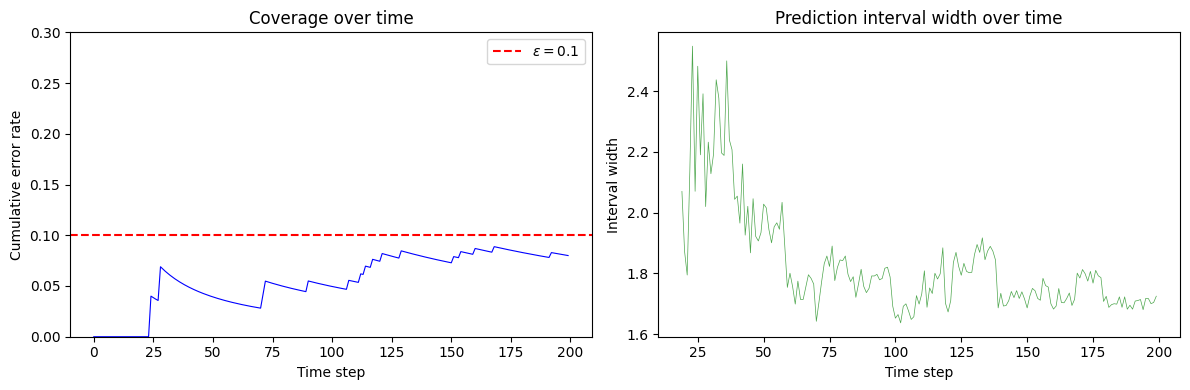

In [4]:
# Visualise coverage over time
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cumulative error rate
cum_errors = np.cumsum(errors) / np.arange(1, N + 1)
axes[0].plot(cum_errors, "b-", linewidth=0.8)
axes[0].axhline(0.1, color="r", linestyle="--", label=r"$\varepsilon = 0.1$")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Cumulative error rate")
axes[0].set_title("Coverage over time")
axes[0].legend()
axes[0].set_ylim(0, 0.3)

# Interval widths
finite_widths = [(i, w) for i, w in enumerate(widths) if np.isfinite(w)]
if finite_widths:
    idx, ws = zip(*finite_widths)
    axes[1].plot(idx, ws, "g-", linewidth=0.5, alpha=0.7)
    axes[1].set_xlabel("Time step")
    axes[1].set_ylabel("Interval width")
    axes[1].set_title("Prediction interval width over time")

plt.tight_layout()
plt.show()

#### Multi-level predictions

You can request prediction intervals at multiple significance levels simultaneously by passing an array-like `epsilon`. This returns a `MultiLevelPredictionInterval`:

In [5]:
# Multi-level prediction in a single call
cp_ml = ConformalRidgeRegressor(a=1.0, epsilon=0.1)
cp_ml.learn_initial_training_set(X[:150], y[:150])

# Pass multiple epsilons → MultiLevelPredictionInterval
epsilons = [0.01, 0.05, 0.1, 0.2]
intervals = cp_ml.predict(X[150], epsilon=epsilons)

print(f"True value: {y[150]:.3f}")
print(f"Intervals at multiple levels:")
for eps, pred_interval in intervals:
    contains = "✓" if y[150] in pred_interval else "✗"
    print(f"  ε={eps:.2f}: [{pred_interval.lower:.3f}, {pred_interval.upper:.3f}]"
          f"  width={pred_interval.width():.3f}  {contains}")

# Access specific level
print(f"\nAccess by level: intervals[0.1] = {intervals[0.1]}")
print(f"Coverage: {intervals.coverage(y[150])}")

True value: 2.039
Intervals at multiple levels:
  ε=0.01: [-inf, inf]  width=inf  ✓
  ε=0.05: [0.714, 2.855]  width=2.141  ✓
  ε=0.10: [0.963, 2.650]  width=1.686  ✓
  ε=0.20: [1.097, 2.359]  width=1.263  ✓

Access by level: intervals[0.1] = (0.963070232591688, 2.649549507351824)
Coverage: {0.01: True, 0.05: True, 0.1: True, 0.2: True}


#### Batch initialisation

Alternatively, you can initialise with a training set and then predict new points. This is useful when you already have labelled data.

In [6]:
# Split into training and test
n_train = 50
cp_batch = ConformalRidgeRegressor(a=1.0, epsilon=0.1)
cp_batch.learn_initial_training_set(X[:n_train], y[:n_train])

# Now predict the remaining points
for i in range(n_train, min(n_train + 5, N)):
    interval = cp_batch.predict(X[i], epsilon=0.1)
    print(
        f"  x={X[i,:2].round(2)}...  y={y[i]:.3f}"
        f"  interval=[{interval.lower:.3f}, {interval.upper:.3f}]"
        f"  width={interval.width():.3f}"
    )
    cp_batch.learn_one(X[i], y[i])

  x=[ 1.63 -1.04]...  y=3.272  interval=[2.388, 4.416]  width=2.028
  x=[-0.04  1.94]...  y=-2.786  interval=[-3.393, -1.377]  width=2.016
  x=[0.69 1.05]...  y=-0.490  interval=[-1.172, 0.773]  width=1.945
  x=[ 0.91 -0.53]...  y=2.187  interval=[1.565, 3.465]  width=1.901
  x=[0.53 0.14]...  y=0.130  interval=[-0.889, 1.065]  width=1.953


#### P-values

The conformal p-value for an example $(x, y)$ tells us how conforming the label $y$ is relative to the training data. Under exchangeability, p-values are uniformly distributed on $[0, 1]$.

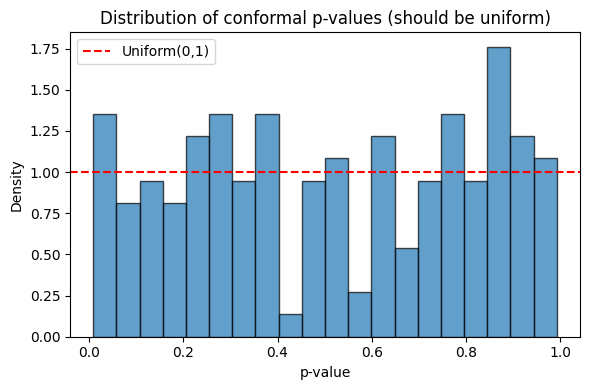

In [7]:
# Collect p-values online
cp_pval = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_pval.learn_initial_training_set(X[:50], y[:50])

p_values = []
for i in range(50, N):
    p = cp_pval.compute_p_value(X[i], y[i])
    p_values.append(p)
    cp_pval.learn_one(X[i], y[i])

# P-values should be approximately uniform
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(p_values, bins=20, density=True, alpha=0.7, edgecolor="black")
ax.axhline(1.0, color="r", linestyle="--", label="Uniform(0,1)")
ax.set_xlabel("p-value")
ax.set_ylabel("Density")
ax.set_title("Distribution of conformal p-values (should be uniform)")
ax.legend()
plt.tight_layout()
plt.show()

### 1.2 Kernel Ridge Regression

`KernelConformalRidgeRegressor` extends ridge regression to nonlinear settings using kernel methods. This is useful when the relationship between features and response is nonlinear.

In [8]:
from online_cp import KernelConformalRidgeRegressor, GaussianKernel

# Generate nonlinear data
N_nl = 150
X_nl = np.random.uniform(-3, 3, (N_nl, 2))
y_nl = np.sin(X_nl[:, 0]) + 0.5 * X_nl[:, 1] ** 2 + np.random.normal(0, 0.3, N_nl)

# Use Gaussian (RBF) kernel
kernel = GaussianKernel(sigma=1.5)
cp_kernel = KernelConformalRidgeRegressor(kernel=kernel, a=0.5, epsilon=0.1)
cp_kernel.learn_initial_training_set(X_nl[:50], y_nl[:50])

# Process the rest online
errors_kernel = []
for i in range(50, N_nl):
    interval = cp_kernel.predict(X_nl[i], epsilon=0.1)
    errors_kernel.append(y_nl[i] not in interval)
    cp_kernel.learn_one(X_nl[i], y_nl[i])

print(f"Kernel ridge — empirical error rate: {np.mean(errors_kernel):.3f} (target \u2264 0.1)")

Kernel ridge — empirical error rate: 0.160 (target ≤ 0.1)


### 1.3 Lasso Regression

`ConformalLassoRegressor` implements exact conformal prediction using the Lasso (or elastic net) via a piecewise linear homotopy algorithm (Lei, 2018). This is particularly useful in high-dimensional settings where sparsity is expected.

In [9]:
from online_cp import ConformalLassoRegressor

# High-dimensional sparse data
N_lasso = 100
p_lasso = 20
X_lasso = np.random.normal(size=(N_lasso, p_lasso))
beta_sparse = np.zeros(p_lasso)
beta_sparse[:4] = [3.0, -2.0, 1.5, -1.0]  # Only 4 non-zero coefficients
y_lasso = X_lasso @ beta_sparse + np.random.normal(0, 0.5, N_lasso)

# Create conformal Lasso regressor
cp_lasso = ConformalLassoRegressor(lam=0.5, epsilon=0.1, rnd_state=42)
cp_lasso.learn_initial_training_set(X_lasso[:40], y_lasso[:40])

# Run online
errors_lasso = []
widths_lasso = []
for i in range(40, N_lasso):
    interval = cp_lasso.predict(X_lasso[i], epsilon=0.1)
    errors_lasso.append(y_lasso[i] not in interval)
    widths_lasso.append(interval.width())
    cp_lasso.learn_one(X_lasso[i], y_lasso[i])

print(f"Conformal Lasso — empirical error rate: {np.mean(errors_lasso):.3f} (target \u2264 0.1)")
print(f"Average interval width: {np.mean(widths_lasso):.3f}")

Conformal Lasso — empirical error rate: 0.083 (target ≤ 0.1)
Average interval width: 2.034


The Lasso also supports **automatic tuning** of the regularisation parameter via cross-validation:

In [10]:
cp_lasso_auto = ConformalLassoRegressor(
    lam=1.0, autotune=True, n_folds=5, epsilon=0.1, rnd_state=0
)
cp_lasso_auto.learn_initial_training_set(X_lasso[:40], y_lasso[:40])
print(f"Auto-tuned \u03bb = {cp_lasso_auto.lam:.4f}")

Auto-tuned λ = 0.5328


### 1.4 Available kernels

The package provides several kernel functions for kernel-based methods:

In [11]:
from online_cp import (
    GaussianKernel,
    LinearKernel,
    PolynomialKernel,
    PeriodicKernel,
    LinearCombinationKernel,
)

# Gaussian (RBF) kernel: k(x,y) = exp(-||x-y||² / 2σ²)
k_gauss = GaussianKernel(sigma=1.0)

# Linear kernel: k(x,y) = x·y
k_linear = LinearKernel()

# Polynomial kernel: k(x,y) = (x·y + c)^d
k_poly = PolynomialKernel(d=3, c=1.0)

# Periodic kernel: useful for seasonal/cyclical data
k_periodic = PeriodicKernel(p=2 * np.pi, s=1.0)

# Combine kernels via linear combination
k_combined = LinearCombinationKernel(
    kernels=[k_gauss, k_linear], weights=[0.7, 0.3]
)

print("Available kernels: Gaussian, Linear, Polynomial, Periodic, LinearCombination")

Available kernels: Gaussian, Linear, Polynomial, Periodic, LinearCombination


---
## 2. Conformal Classifiers

Conformal classifiers produce prediction *sets* — subsets of the label space that are guaranteed to contain the true label with probability at least $1 - \varepsilon$.

### 2.1 k-Nearest Neighbours

In [12]:
from online_cp import ConformalNearestNeighboursClassifier
from sklearn.datasets import make_classification

# Generate a 3-class classification problem
N_cls = 300
X_cls, y_cls = make_classification(
    n_samples=N_cls,
    n_features=5,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=3,
)
label_space = np.array([0, 1, 2])

# Create conformal kNN classifier
cp_knn = ConformalNearestNeighboursClassifier(
    k=5, label_space=label_space, epsilon=0.1, rnd_state=42
)
cp_knn.learn_initial_training_set(X_cls[:60], y_cls[:60])

# Process online
errors_knn = []
sizes_knn = []
for i in range(60, N_cls):
    Gamma = cp_knn.predict(X_cls[i], epsilon=0.1)
    errors_knn.append(y_cls[i] not in Gamma)
    sizes_knn.append(len(Gamma))
    cp_knn.learn_one(X_cls[i], y_cls[i])

print(f"kNN classifier — empirical error rate: {np.mean(errors_knn):.3f} (target ≤ 0.1)")
print(f"Average prediction set size: {np.mean(sizes_knn):.2f} (out of {len(label_space)} classes)")
print(f"Fraction of singletons (certain predictions): {np.mean(np.array(sizes_knn) == 1):.2f}")
print(f"Fraction of empty sets: {np.mean(np.array(sizes_knn) == 0):.2f}")

kNN classifier — empirical error rate: 0.092 (target ≤ 0.1)
Average prediction set size: 0.97 (out of 3 classes)
Fraction of singletons (certain predictions): 0.95
Fraction of empty sets: 0.04


A prediction set of size 1 means we are confident about the class. A set containing multiple labels indicates uncertainty. An empty prediction set means all labels look unusual — this happens at most $\varepsilon$ of the time.

### 2.2 Support Vector Machine

In [13]:
from online_cp import ConformalSupportVectorMachine

# Conformal SVM with RBF kernel
cp_svm = ConformalSupportVectorMachine(
    kernel="rbf",
    sigma=1.0,
    C=10.0,
    label_space=label_space,
    epsilon=0.1,
    rnd_state=42,
)
cp_svm.learn_initial_training_set(X_cls[:60], y_cls[:60])

errors_svm = []
sizes_svm = []
for i in range(60, N_cls):
    Gamma = cp_svm.predict(X_cls[i], epsilon=0.1)
    errors_svm.append(y_cls[i] not in Gamma)
    sizes_svm.append(len(Gamma))
    cp_svm.learn_one(X_cls[i], y_cls[i])

print(f"SVM classifier — empirical error rate: {np.mean(errors_svm):.3f} (target \u2264 0.1)")
print(f"Average prediction set size: {np.mean(sizes_svm):.2f}")

SVM classifier — empirical error rate: 0.092 (target ≤ 0.1)
Average prediction set size: 1.35


### 2.3 Multiple significance levels

A key feature of conformal prediction is that you can produce prediction sets at *any* significance level from the same underlying model. Smaller $\varepsilon$ gives wider (more conservative) sets; larger $\varepsilon$ gives narrower (more efficient) sets.

Pass an array-like `epsilon` to `predict()` to get a `MultiLevelPredictionSet` in a single call:

In [14]:
# Demonstrate multiple significance levels in a single call
cp_multi = ConformalNearestNeighboursClassifier(
    k=5, label_space=label_space, epsilon=0.05, rnd_state=42
)
cp_multi.learn_initial_training_set(X_cls[:100], y_cls[:100])

x_example = X_cls[100]
y_example = y_cls[100]

# Pass multiple epsilons at once → MultiLevelPredictionSet
epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]
Gamma = cp_multi.predict(x_example, epsilon=epsilons)

print(f"True label: {y_example}")
print(f"Predictions at different significance levels:")
for eps, pred_set in Gamma:
    print(f"  ε={eps:.2f}: Γ = {pred_set.elements}  (size {len(pred_set)})")

# Access a specific level
print(f"\nAccess by level: Gamma[0.1] = {Gamma[0.1].elements}")
print(f"Coverage check: {Gamma.coverage(y_example)}")

True label: 2
Predictions at different significance levels:
  ε=0.01: Γ = [0 2]  (size 2)
  ε=0.05: Γ = [2]  (size 1)
  ε=0.10: Γ = [2]  (size 1)
  ε=0.20: Γ = []  (size 0)
  ε=0.50: Γ = []  (size 0)

Access by level: Gamma[0.1] = [2]
Coverage check: {0.01: True, 0.05: True, 0.1: True, 0.2: False, 0.5: False}


---
## 3. Conformal Predictive Systems (CPS)

Conformal predictive systems go beyond prediction intervals — they produce full **predictive distributions**. A conformal predictive distribution (CPD) assigns to each candidate label $y$ a value $Q(y) \in [0, 1]$, forming a step function that can be used to:
- Compute prediction intervals at any significance level
- Make point predictions
- Compute expected utilities for decision-making

### 3.1 Ridge Prediction Machine

In [15]:
from online_cp import RidgePredictionMachine

# Same regression data as before
cps = RidgePredictionMachine(a=1.0)
cps.learn_initial_training_set(X[:50], y[:50])

# Get a conformal predictive distribution for a new point
x_new = X[50]
y_true = y[50]

cpd = cps.predict_cpd(x_new)
print(f"True label: {y_true:.3f}")
print(f"CPD evaluated at true label: Q(y_true) = {cpd(y_true, tau=0.5):.3f}")
print(f"  (should be \u2248 uniform on [0,1] under exchangeability)")

True label: 3.272
CPD evaluated at true label: Q(y_true) = 0.500
  (should be ≈ uniform on [0,1] under exchangeability)


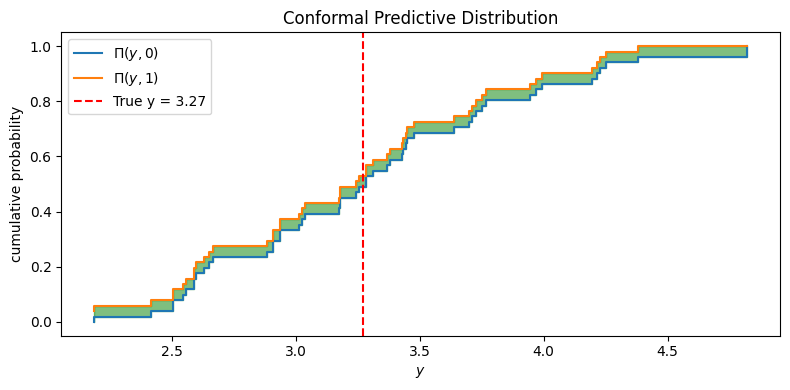

In [16]:
# Plot the conformal predictive distribution
fig = cpd.plot()
fig.set_size_inches(8, 4)
ax = fig.axes[0]
ax.axvline(y_true, color="red", linestyle="--", linewidth=1.5, label=f"True y = {y_true:.2f}")
ax.legend()
ax.set_title("Conformal Predictive Distribution")
fig.tight_layout()
fig

The shaded region between $\Pi(y, 0)$ and $\Pi(y, 1)$ represents the imprecision of the predictive distribution. A random tie-breaking parameter $\tau \sim \text{Uniform}(0,1)$ selects a specific distribution $\Pi(y, \tau)$ from this band.

#### Prediction sets from CPDs

In [17]:
# Extract prediction intervals at different significance levels
tau = np.random.uniform()  # random tie-breaking

print(f"Prediction intervals from CPD (\u03c4 = {tau:.3f}):")
for eps in [0.01, 0.05, 0.1, 0.2]:
    interval = cpd.predict_set(tau=tau, epsilon=eps)
    contains = "\u2713" if y_true in interval else "\u2717"
    print(
        f"  \u03b5={eps:.2f}: [{interval.lower:.3f}, {interval.upper:.3f}]"
        f"  width={interval.width():.3f}  {contains}"
    )

Prediction intervals from CPD (τ = 0.271):
  ε=0.01: [2.186, inf]  width=inf  ✓
  ε=0.05: [2.416, 4.822]  width=2.406  ✓
  ε=0.10: [2.503, 4.380]  width=1.877  ✓
  ε=0.20: [2.544, 4.217]  width=1.673  ✓


#### Online CPS with coverage tracking

In [18]:
# Run CPS online and track coverage
cps_online = RidgePredictionMachine(a=1.0)
cps_online.learn_initial_training_set(X[:30], y[:30])

cps_errors = []
cps_p_values = []
rng = np.random.default_rng(42)

for i in range(30, N):
    tau = rng.uniform()
    cpd = cps_online.predict_cpd(X[i])

    # Prediction interval
    interval = cpd.predict_set(tau=tau, epsilon=0.1)
    cps_errors.append(y[i] not in interval)

    # The CPD evaluated at the true label gives a (smoothed) p-value
    p = cpd(y[i], tau)
    cps_p_values.append(p)

    cps_online.learn_one(X[i], y[i])

print(f"CPS — empirical error rate: {np.mean(cps_errors):.3f} (target \u2264 0.1)")
print(f"P-values mean: {np.mean(cps_p_values):.3f} (should be \u2248 0.5)")

CPS — empirical error rate: 0.094 (target ≤ 0.1)
P-values mean: 0.522 (should be ≈ 0.5)


### 3.2 Kernel Ridge Prediction Machine

For nonlinear problems, use `KernelRidgePredictionMachine`:

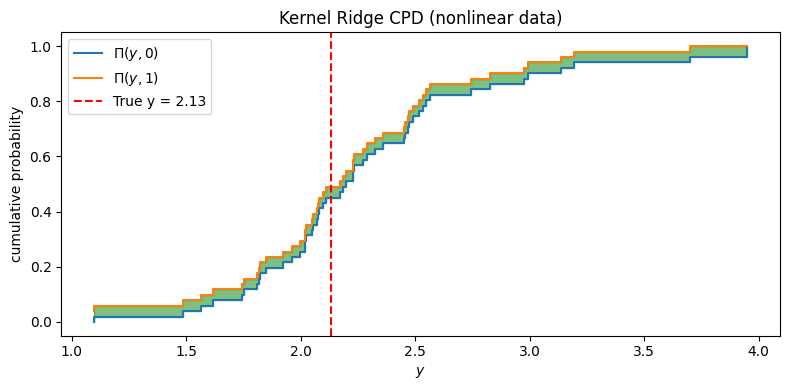

In [19]:
from online_cp import KernelRidgePredictionMachine

kernel = GaussianKernel(sigma=1.5)
cps_kernel = KernelRidgePredictionMachine(kernel=kernel, a=0.5)
cps_kernel.learn_initial_training_set(X_nl[:50], y_nl[:50])

# A single prediction
cpd_nl = cps_kernel.predict_cpd(X_nl[50])
fig = cpd_nl.plot()
fig.set_size_inches(8, 4)
ax = fig.axes[0]
ax.axvline(y_nl[50], color="red", linestyle="--", label=f"True y = {y_nl[50]:.2f}")
ax.legend()
ax.set_title("Kernel Ridge CPD (nonlinear data)")
fig.tight_layout()
fig

### 3.3 Nearest Neighbours Prediction Machine

`NearestNeighboursPredictionMachine` uses k-nearest neighbours as the base model:

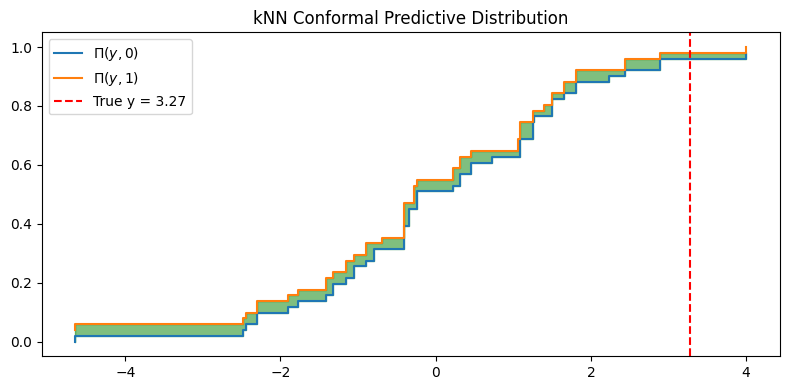

In [20]:
from online_cp import NearestNeighboursPredictionMachine

cps_knn = NearestNeighboursPredictionMachine(k=37)
cps_knn.learn_initial_training_set(X[:50], y[:50])

cpd_knn = cps_knn.predict_cpd(X[50])
fig = cpd_knn.plot()
fig.set_size_inches(8, 4)
ax = fig.axes[0]
ax.axvline(y[50], color="red", linestyle="--", label=f"True y = {y[50]:.2f}")
ax.legend()
ax.set_title("kNN Conformal Predictive Distribution")
fig.tight_layout()
fig

---
## 4. Evaluation

The `metrics` module provides composable, stateful metric objects that accumulate results step-by-step. Metrics are combined with the `+` operator, and the `progressive_val` function runs the full test-then-train loop for you.

### Available metrics

| Metric | Description |
|--------|-------------|
| `ErrorRate` | 1 if the true label is outside the prediction set |
| `ObservedExcess` | Number of false labels in the prediction set |
| `ObservedFuzziness` | Measures calibration via p-values |
| `SetSize` | Size of the prediction set (classifiers) |
| `IntervalWidth` | Width of prediction intervals (regressors) |
| `WinklerScore` | Winkler interval score (penalises width + miscoverage) |
| `CRPS` | Continuous Ranked Probability Score (for CPDs) |

In [21]:
from online_cp import ErrorRate, IntervalWidth, WinklerScore
from online_cp.evaluate import progressive_val

# Set up evaluation with composable metrics
metric = ErrorRate() + IntervalWidth() + WinklerScore()

cp_eval = ConformalRidgeRegressor(a=1.0, epsilon=0.1, rnd_state=0)
cp_eval.learn_initial_training_set(X[:50], y[:50])

# Run progressive validation (test-then-train loop)
progressive_val(cp_eval, X[50:], y[50:], epsilon=0.1, metric=metric)

# Summary statistics
result = metric.get()
for name, value in result.items():
    print(f"{name}: {value:.4f}")

ErrorRate: 0.0933
IntervalWidth: 1.7683
WinklerScore: 2.1328


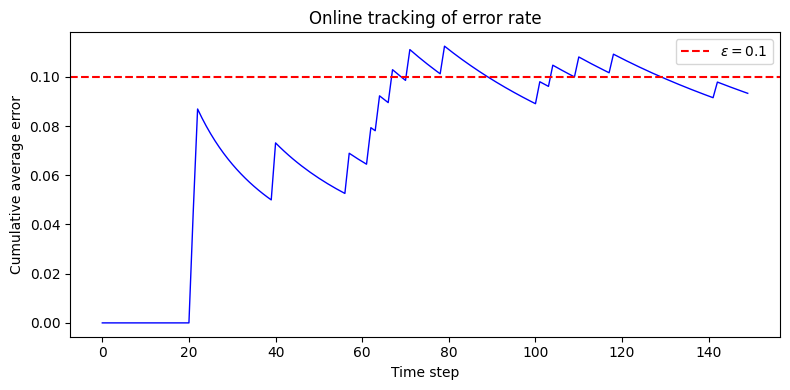

In [22]:
# Plot cumulative average error rate
fig, ax = plt.subplots(figsize=(8, 4))
err_metric = metric["ErrorRate"]
ax.plot(err_metric.cumulative_mean(), "b-", linewidth=1)
ax.axhline(0.1, color="r", linestyle="--", label=r"$\varepsilon = 0.1$")
ax.set_xlabel("Time step")
ax.set_ylabel("Cumulative average error")
ax.set_title("Online tracking of error rate")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Conformal Test Martingales

Conformal test martingales provide a way to test whether the data is exchangeable **online**. If the data is exchangeable, the conformal p-values are uniform, and the martingale stays bounded. If exchangeability is violated (e.g., due to distribution shift), the martingale grows, signalling a departure.

The martingale $M_n$ satisfies: under exchangeability, $\mathbb{E}[M_n] \leq 1$ for all $n$. So if $M_n$ becomes large (say $> 100$), we have strong evidence against exchangeability.

### 5.1 Basic usage with PluginMartingale

In [23]:
from online_cp import PluginMartingale, GaussianKDE

# First: generate exchangeable data and verify martingale stays small
N_mart = 300
rng_mart = np.random.default_rng(123)
X_exch = rng_mart.normal(size=(N_mart, 3))
y_exch = X_exch @ np.array([1, -1, 0.5]) + rng_mart.normal(0, 0.3, N_mart)

# Compute p-values using a conformal regressor
cp_mart = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_mart.learn_initial_training_set(X_exch[:30], y_exch[:30])

martingale = PluginMartingale(betting_strategy=GaussianKDE(min_sample_size=50))

for i in range(30, N_mart):
    p = cp_mart.compute_p_value(X_exch[i], y_exch[i])
    martingale.update_martingale_value(p)
    cp_mart.learn_one(X_exch[i], y_exch[i])

print(f"Final log-martingale value: {martingale.logM:.2f}")
print(f"Final martingale value: {martingale.M:.2f}")
print(f"  (under exchangeability, should stay near 1)")

Final log-martingale value: -3.56
Final martingale value: 0.03
  (under exchangeability, should stay near 1)


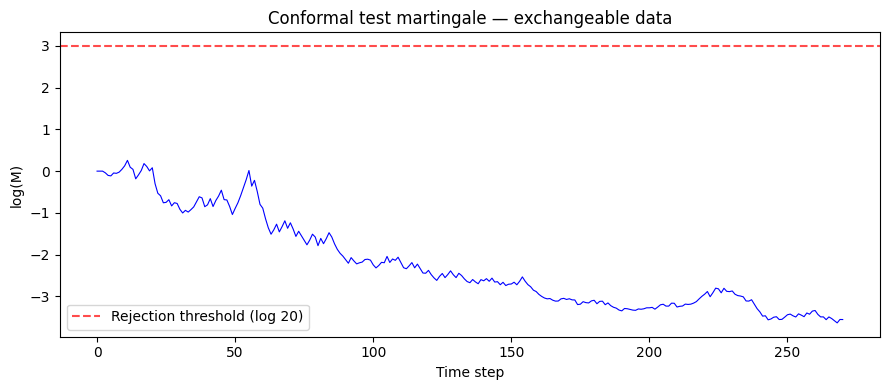

In [24]:
# Plot the martingale
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(martingale.log_martingale_values, "b-", linewidth=0.8)
ax.axhline(np.log(20), color="r", linestyle="--", alpha=0.7, label="Rejection threshold (log 20)")
ax.set_xlabel("Time step")
ax.set_ylabel("log(M)")
ax.set_title("Conformal test martingale — exchangeable data")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Detecting distribution shift

Now let's see what happens when exchangeability is violated. We introduce a sudden shift in the data distribution midway.

/home/johan/Documents/PhD/PREMACOP/OnlineConformalPrediction/src/online_cp/martingale.py:957: UserWarning: Exchangeability assumption likely violated: Max martingale value is 106.12456249456842
  self.check_warning()


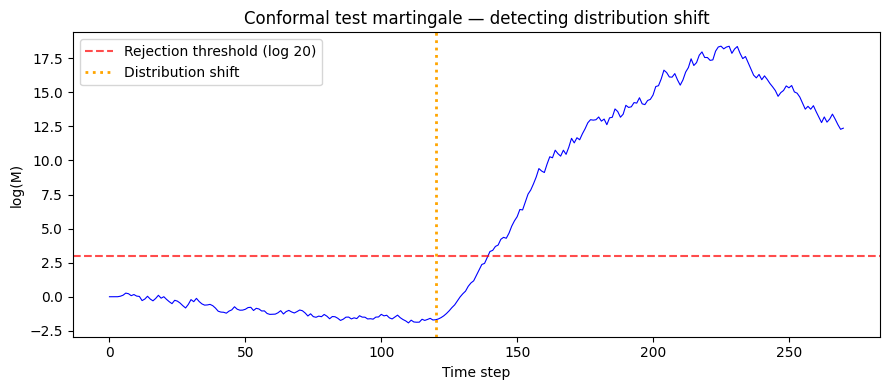

Max log-martingale: 18.4
  → Strong evidence against exchangeability!


In [25]:
# Data with a distribution shift at time 150
N_shift = 300
rng_shift = np.random.default_rng(456)
X_shift = rng_shift.normal(size=(N_shift, 3))
y_shift = np.zeros(N_shift)

# First half: y = X\u03b2 + noise
y_shift[:150] = X_shift[:150] @ np.array([1, -1, 0.5]) + rng_shift.normal(0, 0.3, 150)
# Second half: shift the mean by 3
y_shift[150:] = X_shift[150:] @ np.array([1, -1, 0.5]) + 3.0 + rng_shift.normal(0, 0.3, 150)

# Run conformal predictor + martingale
cp_shift = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_shift.learn_initial_training_set(X_shift[:30], y_shift[:30])

martingale_shift = PluginMartingale(betting_strategy=GaussianKDE(min_sample_size=30))

for i in range(30, N_shift):
    p = cp_shift.compute_p_value(X_shift[i], y_shift[i])
    martingale_shift.update_martingale_value(p)
    cp_shift.learn_one(X_shift[i], y_shift[i])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(martingale_shift.log_martingale_values, "b-", linewidth=0.8)
ax.axhline(np.log(20), color="r", linestyle="--", alpha=0.7, label="Rejection threshold (log 20)")
ax.axvline(150 - 30, color="orange", linestyle=":", linewidth=2, label="Distribution shift")
ax.set_xlabel("Time step")
ax.set_ylabel("log(M)")
ax.set_title("Conformal test martingale — detecting distribution shift")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max log-martingale: {max(martingale_shift.log_martingale_values):.1f}")
print(f"  \u2192 Strong evidence against exchangeability!")

### 5.3 Other betting strategies

The package offers several betting strategies with different trade-offs:

| Strategy | Description |
|----------|-------------|
| `GaussianKDE` | Non-parametric Gaussian kernel density estimation |
| `BetaKernel` | Beta kernel density estimation (better near [0,1] boundaries) |
| `BetaMoments` | Parametric Beta distribution fitted by method of moments |
| `BetaMLE` | Parametric Beta distribution fitted by MLE |
| `FixedStrategy` | Use a fixed betting function (e.g., always bet on $p < 0.5$) |
| `ParticleFilterStrategy` | Particle filter for adaptive parameter estimation |
| `ExpertAggregationStrategy` | Aggregate multiple experts' bets |

In [26]:
from online_cp import SimpleJumper, SimpleMixtureMartingale

# SimpleJumper: a power martingale with a fixed epsilon
# The betting function is f(p) = eps * p^(eps-1)
jumper = SimpleJumper(epsilon=0.92)

cp_shift2 = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_shift2.learn_initial_training_set(X_shift[:30], y_shift[:30])

for i in range(30, N_shift):
    p = cp_shift2.compute_p_value(X_shift[i], y_shift[i])
    jumper.update_martingale_value(p)
    cp_shift2.learn_one(X_shift[i], y_shift[i])

print(f"SimpleJumper final log(M): {jumper.logM:.1f}")
print(f"SimpleJumper final M:      {jumper.M:.1f}")

/home/johan/Documents/PhD/PREMACOP/OnlineConformalPrediction/src/online_cp/martingale.py:1040: UserWarning: Exchangeability assumption likely violated: Max martingale value is 113.92362623014743
  self.check_warning()


SimpleJumper final log(M): 18.9
SimpleJumper final M:      160269581.7


---
## 6. Putting it all together

Here is a complete example showing the full workflow: online learning, prediction, evaluation, and exchangeability monitoring.

In [27]:
from online_cp import (
    ConformalRidgeRegressor,
    RidgePredictionMachine,
    PluginMartingale,
    GaussianKDE,
    ErrorRate,
    IntervalWidth,
    WinklerScore,
)
from online_cp.evaluate import progressive_val

# Generate data
rng = np.random.default_rng(2024)
N_full = 300
X_full = rng.normal(size=(N_full, 4))
beta_full = np.array([2, -1, 0.5, 0])
y_full = X_full @ beta_full + rng.normal(0, 0.5, N_full)

# Initialise components
n_init = 30
cp_full = ConformalRidgeRegressor(a=1.0, epsilon=0.1, rnd_state=0)
metric_full = ErrorRate() + IntervalWidth() + WinklerScore()
mart_full = PluginMartingale(betting_strategy=GaussianKDE(min_sample_size=50))

# Learn initial training set
cp_full.learn_initial_training_set(X_full[:n_init], y_full[:n_init])

# Online processing
for i in range(n_init, N_full):
    x_i, y_i = X_full[i], y_full[i]

    # 1. Prediction interval
    interval = cp_full.predict(x_i, epsilon=0.1)

    # 2. P-value
    p = cp_full.compute_p_value(x_i, y_i)

    # 3. Update metrics
    metric_full.update(y=y_i, Gamma=interval, epsilon=0.1)

    # 4. Update martingale
    mart_full.update_martingale_value(p)

    # 5. Learn
    cp_full.learn_one(x_i, y_i)

# Final summary
print("=" * 50)
print("ONLINE CONFORMAL PREDICTION — SUMMARY")
print("=" * 50)
result = metric_full.get()
print(f"Error rate:      {result['ErrorRate']:.4f}  (target ≤ 0.10)")
print(f"Avg width:       {result['IntervalWidth']:.4f}")
print(f"Winkler score:   {result['WinklerScore']:.4f}")
print(f"Martingale:      {mart_full.M:.2f}  (stays small ⇒ exchangeability OK)")
print("=" * 50)

ONLINE CONFORMAL PREDICTION — SUMMARY
Error rate:      0.0963  (target ≤ 0.10)
Avg width:       1.9108
Winkler score:   2.3221
Martingale:      0.06  (stays small ⇒ exchangeability OK)


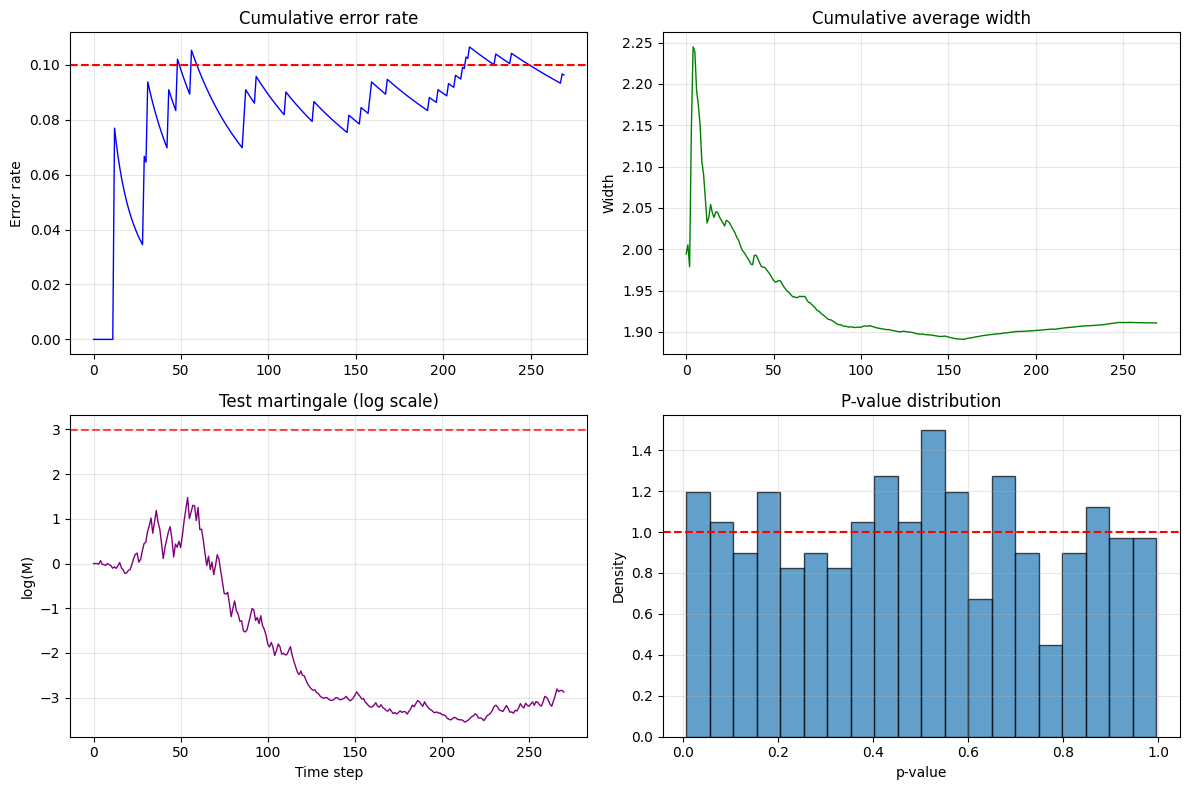

In [28]:
# Final visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Cumulative error
err_full = metric_full["ErrorRate"]
axes[0, 0].plot(err_full.cumulative_mean(), "b-", linewidth=1)
axes[0, 0].axhline(0.1, color="r", linestyle="--")
axes[0, 0].set_title("Cumulative error rate")
axes[0, 0].set_ylabel("Error rate")

# Interval widths
width_full = metric_full["IntervalWidth"]
axes[0, 1].plot(width_full.cumulative_mean(), "g-", linewidth=1)
axes[0, 1].set_title("Cumulative average width")
axes[0, 1].set_ylabel("Width")

# Martingale
axes[1, 0].plot(mart_full.log_martingale_values, color="purple", linewidth=1)
axes[1, 0].axhline(np.log(20), color="r", linestyle="--", alpha=0.7)
axes[1, 0].set_title("Test martingale (log scale)")
axes[1, 0].set_ylabel("log(M)")
axes[1, 0].set_xlabel("Time step")

# P-value histogram
axes[1, 1].hist(mart_full.p_values, bins=20, density=True, alpha=0.7, edgecolor="black")
axes[1, 1].axhline(1.0, color="r", linestyle="--")
axes[1, 1].set_title("P-value distribution")
axes[1, 1].set_xlabel("p-value")
axes[1, 1].set_ylabel("Density")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Summary of classes

### Regressors
| Class | Underlying model | Key parameters |
|-------|-----------------|----------------|
| `ConformalRidgeRegressor` | Ridge regression | `a` (ridge penalty) |
| `KernelConformalRidgeRegressor` | Kernel ridge regression | `kernel`, `a` |
| `ConformalLassoRegressor` | Lasso / Elastic net | `lam`, `rho` |

### Classifiers
| Class | Underlying model | Key parameters |
|-------|-----------------|----------------|
| `ConformalNearestNeighboursClassifier` | k-NN | `k`, `label_space` |
| `ConformalSupportVectorMachine` | SVM | `kernel`, `C`, `sigma` |

### Conformal Predictive Systems
| Class | Underlying model | Key parameters |
|-------|-----------------|----------------|
| `RidgePredictionMachine` | Ridge regression | `a` |
| `KernelRidgePredictionMachine` | Kernel ridge regression | `kernel`, `a` |
| `NearestNeighboursPredictionMachine` | k-NN | `k` |
| `DempsterHillConformalPredictiveSystem` | Dempster-Hill | — |

### Common API pattern

All classes follow the same interface:

```python
# Initialise
model = ConformalRidgeRegressor(a=1.0, epsilon=0.1)

# Option A: Learn a batch training set
model.learn_initial_training_set(X_train, y_train)

# Option B: Learn point by point
model.learn_one(x, y)

# Predict at a single level
Gamma = model.predict(x_new, epsilon=0.1)

# Predict at multiple levels simultaneously
Gamma = model.predict(x_new, epsilon=[0.01, 0.05, 0.1, 0.2])
Gamma[0.1]           # access specific level
Gamma.coverage(y)    # {eps: bool} at each level

# Compute p-value
p = model.compute_p_value(x_new, y_new)
```

### Evaluation

```python
from online_cp import ErrorRate, IntervalWidth, WinklerScore
from online_cp.evaluate import progressive_val

metric = ErrorRate() + IntervalWidth() + WinklerScore()
progressive_val(model, X_test, y_test, epsilon=0.1, metric=metric)
print(metric)
```

### References

- Vovk, Gammerman, Shafer. *Algorithmic Learning in a Random World* (2nd ed). Springer, 2022.